In [34]:
# Initialize Otter
import otter
grader = otter.Notebook("timeSeries.ipynb")

## Lecture Section

In this lecture, we will introduce time series analysis. We will cover:

* What is a lag?
* The Autocorrelation Function (ACF)
* The Partial Autocorrelation Function (PACF)
* Fitting an ARIMA model
* Improving a time series model with residual modeling

### Time-series Analysis

Lastly, let's do some brief time-series work. We are going to use the `sunspots` dataset - it is considered the longest recorded dataset with data recorded since 1700!

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf

### What is a Lag?

In a time series, a **lag** is a shift of the series by some number of time steps. For example, if today is April 7th, 2027, then lag -365 shifts us back to approximately April 7th, 2026.

$$\text{April 7, 2027} \xrightarrow{\text{lag} = -365} \text{April 7, 2026}$$

Lags are the core building block of time series models. When we ask "how correlated is today's sunspot count with the count from 11 years ago?", we are computing the correlation at lag 11.

In [36]:
df_ts = sm.datasets.sunspots.load_pandas().data
df_ts["YEAR"] = pd.to_datetime(df_ts["YEAR"], format="%Y")
df_ts.set_index("YEAR", inplace=True)
df_ts = df_ts["SUNACTIVITY"]
df_ts.head()

YEAR
1700-01-01     5.0
1701-01-01    11.0
1702-01-01    16.0
1703-01-01    23.0
1704-01-01    36.0
Name: SUNACTIVITY, dtype: float64

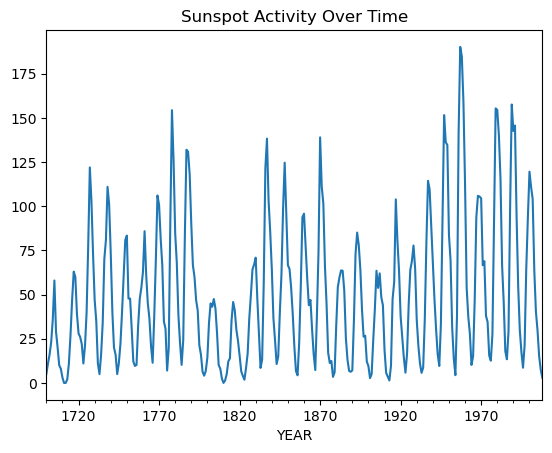

In [37]:
df_ts.plot(title="Sunspot Activity Over Time")
plt.show()

### The Autocorrelation Function (ACF)

The **ACF** tells us how correlated a time series is with lagged versions of itself. At lag 0, the correlation is always 1.0 (a series is perfectly correlated with itself). As the lag increases, the correlation typically decreases.

When the ACF bars decay slowly and gradually, that suggests the series has a trend or is non-stationary. When the bars cut off sharply after lag $q$, that is a sign of a **moving average (MA) process** of order $q$.

### The Partial Autocorrelation Function (PACF)

The **PACF** is similar, but it removes the influence of the intermediate lags. Think of it as the "direct" relationship between a value and its lagged version, after controlling for everything in between.

When the PACF cuts off sharply after lag $p$, that is a sign of an **autoregressive (AR) process** of order $p$. A spike in the PACF at a seasonal period (e.g., lag 12 for monthly data) is a sign of **seasonality** - this means your data has a pattern that repeats every $p$ number of lags.

Before we run an ARIMA model, you'll want to look at both plots to determine the order $(p, d, q)$.

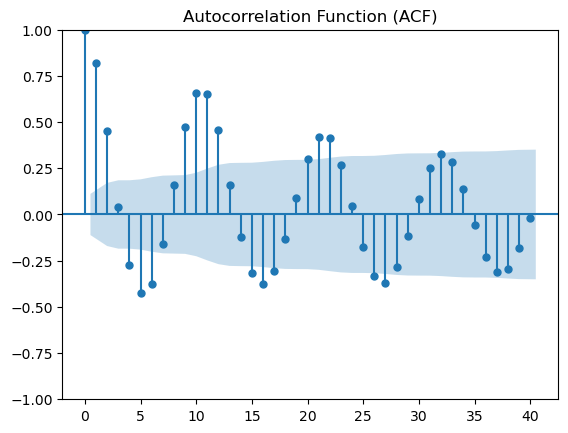

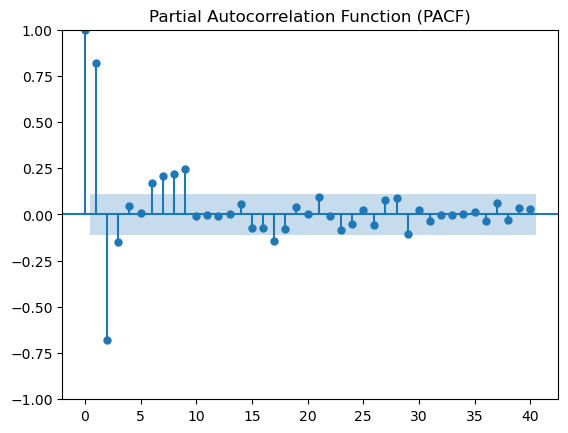

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_ts, lags=40)  # lags=40 means show autocorrelations up to lag 40
plt.title('Autocorrelation Function (ACF)')
plt.show()

# Plot PACF
plot_pacf(df_ts, lags=40)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

The pacf shows seasonality at lag 2! This will be our $p$ value in our ARIMA model.

Our acf graph doesn't have any significant spikes - if it did, we'd look for the lag where they stop occuring, and that would be our $q$ value. 

We will not concern ourselves with the middle $d$ value. It is far easier to use `auto.arima`, but then you wouldn't learn anything!

For an ARIMA model, we call `ARIMA` from `statsmodels.tsa.arima.model`. Then, we pass in our data, our order (p, d, q) or (AR, I, MA), and we `.fit()`. That's it!

In [39]:
from statsmodels.tsa.arima.model import ARIMA
model_ts = ARIMA(df_ts, order=(2, 0, 0)).fit()
print(model_ts.summary())

                               SARIMAX Results                                
Dep. Variable:            SUNACTIVITY   No. Observations:                  309
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1307.319
Date:                Wed, 22 Apr 2026   AIC                           2622.637
Time:                        22:09:39   BIC                           2637.570
Sample:                    01-01-1700   HQIC                          2628.607
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.7462      3.938     12.631      0.000      42.027      57.465
ar.L1          1.3906      0.037     37.694      0.000       1.318       1.463
ar.L2         -0.6886      0.036    -19.363      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


We can grab diagnostic plots, too.

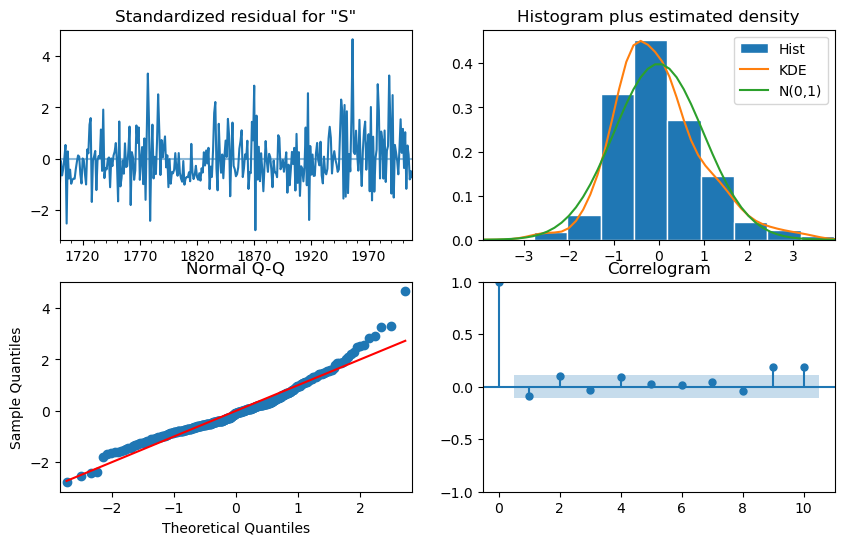

In [40]:
model_ts.plot_diagnostics(figsize=(10, 6))
plt.show()

From the plot on the top left, we see a fairly random scatter around 0, no clear patterns or trends, and outliers are not very prominent. The top right graph shows residuals that are roughly normally distributed, with a bit of right-skewness. The bottom left plot shows points lying close to the red line, with some deviation at the tails (a common result). The bottom right plot shows all points within the blue bounds, meaning the residuals are within white noise. (The first will always be 1.0) Everything looks good!

### Improving Performance with Residual Modeling

One powerful technique for improving time series forecasts is to model the **residuals** left over by the initial model.

The idea is:
1. Fit a time series model (like ARIMA) to your data and extract the residuals.
2. Model those residuals using any other model you like (another time series model, a regression, a machine learning model, etc.).
3. Combine the two models — the original model's prediction plus the residual model's prediction gives better overall performance.

$$\hat{y} = \text{ARIMA prediction} + \text{residual model prediction}$$

This works because the residuals capture structure that the first model missed. If the residuals look like white noise (as in our diagnostic plot above), there is nothing left to model. But if they show a pattern, a second model can pick that up. The second model doesn't need to be a time series model because residuals are not bound by time!

Residual mean: -0.0927
Residual std:  16.7646


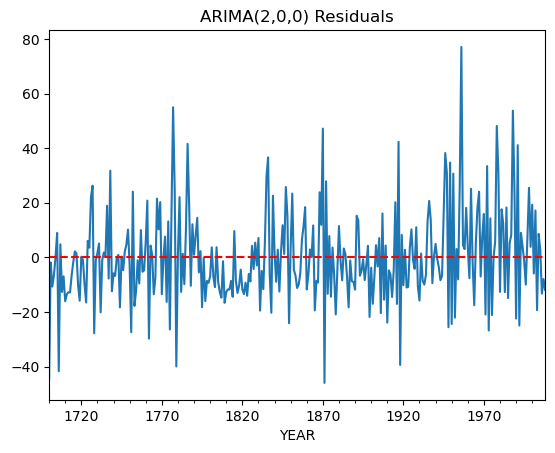

In [41]:
# Example: extracting residuals from the fitted model
residuals = model_ts.resid
print("Residual mean:", round(residuals.mean(), 4))
print("Residual std: ", round(residuals.std(), 4))

residuals.plot(title="ARIMA(2,0,0) Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.show()

## Assignment Section

**Question 1.**

Using the `df_ts` sunspots series (above), compute the following and store your results in the given variable names:

- `acf_values`: the autocorrelation values for lags 0 through 10, using `statsmodels.tsa.stattools.acf` with `nlags=10`

In [42]:
from statsmodels.tsa.stattools import acf

df_ts = sm.datasets.sunspots.load_pandas().data
df_ts["YEAR"] = pd.to_datetime(df_ts["YEAR"], format="%Y")
df_ts.set_index("YEAR", inplace=True)
df_ts = df_ts["SUNACTIVITY"]

acf_values = acf(df_ts, nlags=10)
#print("ACF values for lags 0 to 10: ", acf_values)

In [43]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.**

Fit an ARIMA(3, 0, 0) model to `df_ts`. Store the following:

- `my_model`: the fitted ARIMA model object
- `model_aic`: the AIC of the fitted model
- `ar1_coef`: the first AR coefficient (`ar.L1`)

*Hint: After fitting with `.fit()`, use `.aic` for the AIC and `.params` for the coefficients.*

In [44]:
from statsmodels.tsa.arima.model import ARIMA

my_model = ARIMA(df_ts, order=(3, 0, 0)).fit()
model_aic = my_model.aic
ar1_coef = my_model.params[1]
#print(ar1_coef)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/var/folders/6g/8jp4vl_92xz_5pftljll24pw0000gq/T/ipykernel_2146/2912164314.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ar1_coef = my_model.params[1]


In [45]:
grader.check("q2")

q2 results: All test cases passed!

**Question 3.**

Using `my_model` from Question 2, extract the residuals and compute the following:

- `resid`: the residuals (use `.resid`)
- `resid_mean`: the mean of the residuals
- `resid_std`: the standard deviation of the residuals
- `resid_positive`: the number of residuals that are strictly greater than 0 (an integer)

In [46]:
my_model = ARIMA(df_ts, order=(3, 0, 0)).fit()

resid = my_model.resid
resid_mean = resid.mean()
resid_std = resid.std()
resid_positive = sum(resid > 0)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [47]:
grader.check("q3")

q3 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [49]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!